# Classification de Genre à partir de Texte de Blog - Guide d'Explication Détaillé

## 📋 Aperçu
Ce projet implémente un pipeline d'apprentissage automatique complet pour prédire le sexe des auteurs de blogs basé sur leur style d'écriture et l'utilisation des mots. Le code compare plusieurs approches : modèles d'apprentissage automatique traditionnels, apprentissage profond basé sur des transformeurs (DistilBERT), et réseaux de neurones récurrents (BiLSTM).

## 🔧 Section 1: Importation de Bibliothèques et Configuration

### Objectif
Importer toutes les bibliothèques nécessaires pour le traitement des données, l'apprentissage automatique, l'apprentissage profond et la visualisation.

**Traitement et Analyse des Données :**
- `numpy` : Calculs numériques et opérations sur les tableaux
- `pandas` : Manipulation et analyse des données (lecture CSV, dataframes)
- `matplotlib.pyplot` & `seaborn` : Visualisation des données et graphiques

**Traitement de Texte :**
- `nltk` : Boîte à outils de traitement du langage naturel pour le prétraitement de texte
- `re` : Expressions régulières pour la correspondance de motifs et le nettoyage de texte
- `unicodedata` : Normalisation Unicode pour la suppression des accents
- `Counter` de collections : Comptage des fréquences de mots

**Apprentissage Automatique Traditionnel :**
- `sklearn` : Bibliothèque d'apprentissage automatique complète
  - `train_test_split` : Division des données en ensembles d'entraînement/test
  - `LabelEncoder` : Conversion des étiquettes de texte en nombres
  - Divers classificateurs (RandomForest, SVM, etc.)
  - Métriques d'évaluation (précision, matrice de confusion)

**Apprentissage Profond - PyTorch :**
- `torch` : Framework PyTorch pour les réseaux de neurones
- `transformers` : Bibliothèque Hugging Face pour les modèles pré-entraînés
- `DataLoader` : Traitement efficace par lots des données

**Apprentissage Profond - TensorFlow/Keras :**
- `tensorflow.keras` : API de haut niveau pour les réseaux de neurones
- Prétraitement de texte et couches LSTM

### Pourquoi Ces Bibliothèques ?
- **NLTK** : Standard industriel pour le prétraitement de texte
- **Scikit-learn** : Bibliothèque ML la plus populaire avec API cohérente
- **PyTorch + Transformers** : État de l'art pour les tâches NLP
- **TensorFlow/Keras** : Framework d'apprentissage profond alternatif
- **Seaborn/Matplotlib** : Visualisation de données professionnelle

In [2]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
import warnings
import pickle
import joblib
from collections import Counter
import math

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# Deep Learning - PyTorch
import torch
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Deep Learning - TensorFlow/Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Download NLTK resources
print("Downloading NLTK resources...")
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("punkt_tab", quiet=True)

True


## 📊 Section 2: Chargement et Exploration des Données

### Objectif
Comprendre la structure du dataset, la distribution et les caractéristiques de base.

**Pourquoi nrows=10000 ?**
- Les gros datasets peuvent être coûteux computationnellement
- 10 000 échantillons fournissent suffisamment de données pour l'entraînement tout en gardant un temps de traitement raisonnable
- Bon équilibre entre quantité de données et efficacité computationnelle


In [3]:

# Load dataset
df = pd.read_csv("/kaggle/input/blog-authorship-corpus/blogtext.csv", nrows=10000)
print(f"Original dataset shape: {df.shape}")


Original dataset shape: (10000, 7)


### Sélection de Colonnes 
- Seuls `gender` (variable cible) et `text` (caractéristiques) sont nécessaires
- Supprime les colonnes inutiles qui ne contribuent pas à la prédiction du genre

In [4]:
# Select relevant columns
df = df[["gender", "text"]]
print(f"Selected columns shape: {df.shape}")

# Display basic info
print("\nFirst few rows:")
print(df.head())
print(f"\nUnique genders: {df.gender.unique()}")
print(f"\nGender distribution:")
print(df.gender.value_counts())


Selected columns shape: (10000, 2)

First few rows:
  gender                                               text
0   male             Info has been found (+/- 100 pages,...
1   male             These are the team members:   Drewe...
2   male             In het kader van kernfusie op aarde...
3   male                   testing!!!  testing!!!          
4   male               Thanks to Yahoo!'s Toolbar I can ...

Unique genders: ['male' 'female']

Gender distribution:
gender
male      5916
female    4084
Name: count, dtype: int64


### Mappage de Genre 
**Objectif** : Convertir les étiquettes texte ('male', 'female') en IDs numériques (0, 1)

**Pourquoi** : Les algorithmes d'apprentissage automatique nécessitent des entrées numériques, pas des étiquettes texte


In [5]:
df["gender_id"] = df["gender"].factorize()[0]
gender_id_df = df[["gender", "gender_id"]].drop_duplicates().sort_values("gender_id")
gender_to_id = dict(gender_id_df.values)
id_to_gender = dict(gender_id_df[["gender_id", "gender"]].values)

print(f"\nGender mapping:")
for gender, id_val in gender_to_id.items():
    print(f"{gender}: {id_val}")


Gender mapping:
male: 0
female: 1



### Visualisation des données


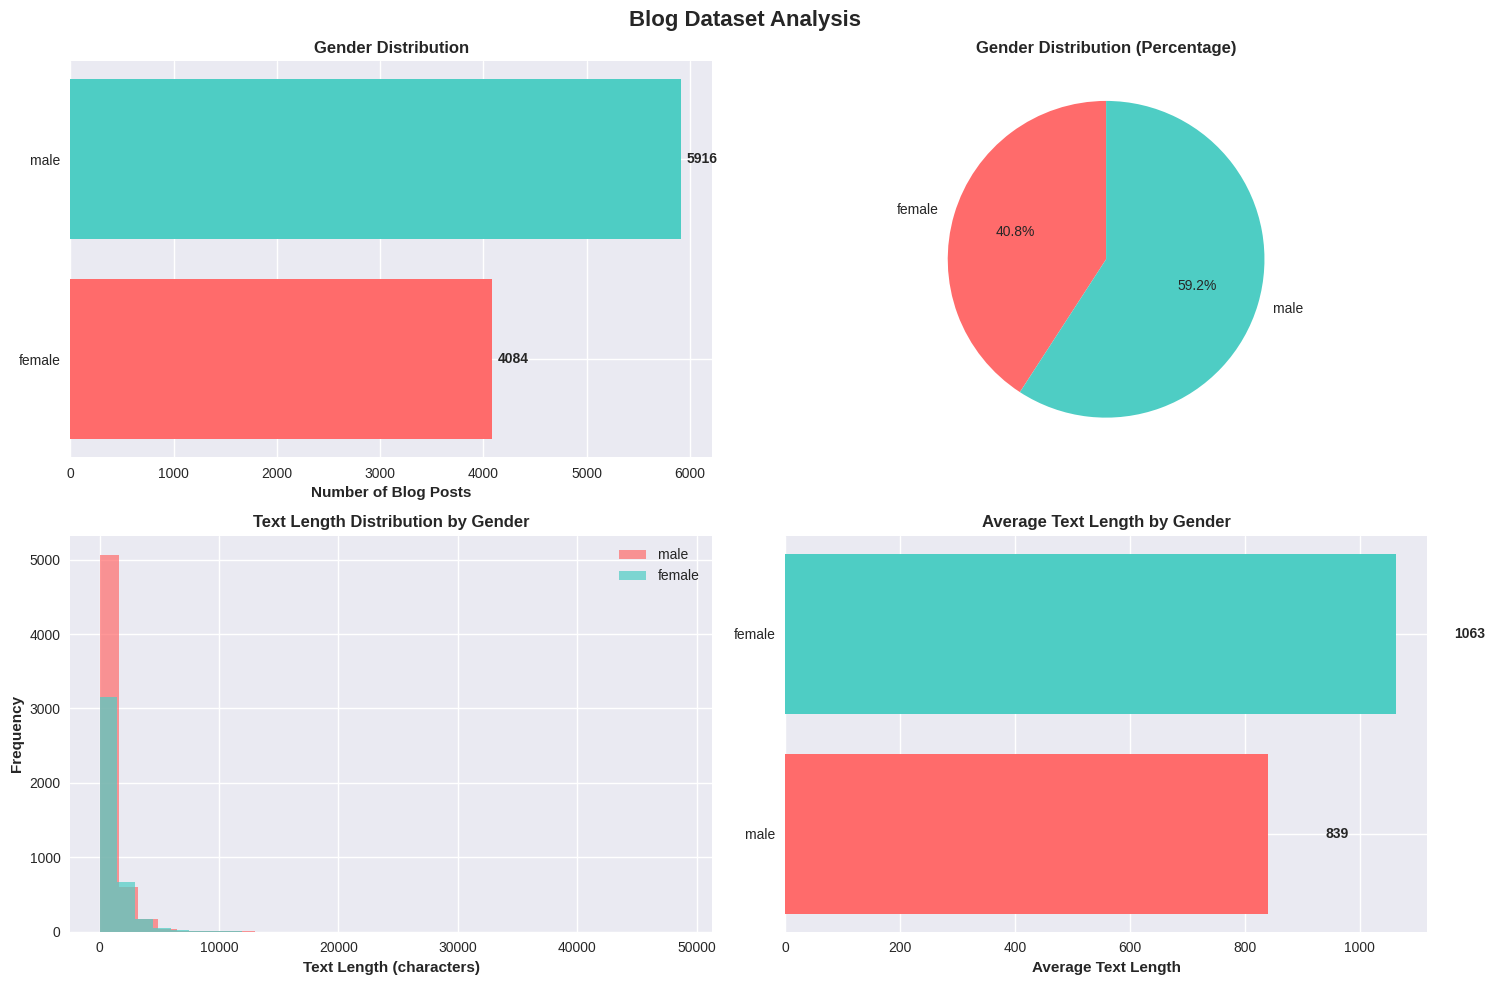


Text Length Statistics:
         count         mean          std   min    25%    50%      75%      max
gender                                                                        
female  4084.0  1063.385896  1430.665660  12.0  245.0  661.0  1405.00  44747.0
male    5916.0   839.783469  1559.459685   4.0  122.0  371.0  1021.25  48828.0


In [6]:
# Create subplots for better visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Blog Dataset Analysis', fontsize=16, fontweight='bold')

# Gender distribution - bar plot
gender_counts = df.groupby("gender").size().sort_values(ascending=True)
axes[0, 0].barh(gender_counts.index, gender_counts.values, color=['#FF6B6B', '#4ECDC4'])
axes[0, 0].set_xlabel('Number of Blog Posts', fontweight='bold')
axes[0, 0].set_title('Gender Distribution', fontweight='bold')
for i, v in enumerate(gender_counts.values):
    axes[0, 0].text(v + 50, i, str(v), va='center', fontweight='bold')

# Gender distribution - pie chart
axes[0, 1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
               colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[0, 1].set_title('Gender Distribution (Percentage)', fontweight='bold')

# Text length distribution
df['text_length'] = df['text'].str.len()
for i, gender in enumerate(df['gender'].unique()):
    data = df[df['gender'] == gender]['text_length']
    axes[1, 0].hist(data, alpha=0.7, bins=30, label=gender, color=['#FF6B6B', '#4ECDC4'][i])
axes[1, 0].set_xlabel('Text Length (characters)', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Text Length Distribution by Gender', fontweight='bold')
axes[1, 0].legend()

# Average text length by gender
avg_length = df.groupby('gender')['text_length'].mean().sort_values(ascending=True)
bars = axes[1, 1].barh(avg_length.index, avg_length.values, color=['#FF6B6B', '#4ECDC4'])
axes[1, 1].set_xlabel('Average Text Length', fontweight='bold')
axes[1, 1].set_title('Average Text Length by Gender', fontweight='bold')
for i, v in enumerate(avg_length.values):
    axes[1, 1].text(v + 100, i, f'{int(v)}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nText Length Statistics:")
print(df.groupby('gender')['text_length'].describe())


## 🧹 Section 3: Prétraitement de Texte

### Objectif
Convertir le texte brut en caractéristiques numériques que les modèles d'apprentissage automatique peuvent traiter.

### Fonction de Prétraitement de Texte 


In [7]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Comprehensive text preprocessing function"""
    text = text.lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r"http\S+|www\S+|<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return tokens

print("Preprocessing text documents...")
docs_tokens = [preprocess_text(doc) for doc in df["text"]]

# Build vocabulary
print("Building vocabulary...")
df_counts = Counter()
for tokens in docs_tokens:
    df_counts.update(set(tokens))


Preprocessing text documents...
Building vocabulary...


### Filtrage de Vocabulaire 

**Pourquoi filtrer avec freq >= 5 ?**
- Les mots apparaissant dans <5 documents sont probablement des fautes de frappe ou des termes très rares
- Réduit la taille du vocabulaire (améliore l'efficacité computationnelle)
- Réduit le surapprentissage (les modèles ne mémoriseront pas les mots rares et bruyants)


In [8]:
vocab = {word for word, freq in df_counts.items() if freq >= 5}
vocab = sorted(vocab)
word_to_index = {word: i for i, word in enumerate(vocab)}

print(f"Vocabulary size: {len(vocab)}")
print(f"Total unique words before filtering: {len(df_counts)}")

Vocabulary size: 11300
Total unique words before filtering: 43349


### Création TF-IDF 

**Pourquoi TF-IDF ?**
- **TF** : Les mots qui apparaissent plus souvent dans un document sont plus importants
- **IDF** : Les mots rares sont plus distinctifs que les mots courants
- **Résultat** : Les mots fréquents dans des documents spécifiques mais rares globalement obtiennent des scores élevés


In [9]:
N = len(docs_tokens)
V = len(vocab)
tfidf_matrix = np.zeros((N, V))

for doc_idx, tokens in enumerate(docs_tokens):
    if doc_idx % 1000 == 0:
        print(f"Processing document {doc_idx}/{N}")

    tf_counts = Counter(tokens)
    for word in tf_counts:
        if word in word_to_index:
            tf = tf_counts[word]
            df_val = df_counts[word]
            idf = math.log((N + 1) / (df_val + 1)) + 1
            tfidf_matrix[doc_idx, word_to_index[word]] = tf * idf

row_norms = np.linalg.norm(tfidf_matrix, axis=1, keepdims=True)
tfidf_matrix = tfidf_matrix / (row_norms + 1e-8)

features = tfidf_matrix
labels = df["gender_id"]

print(f"Final features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Processing document 0/10000
Processing document 1000/10000
Processing document 2000/10000
Processing document 3000/10000
Processing document 4000/10000
Processing document 5000/10000
Processing document 6000/10000
Processing document 7000/10000
Processing document 8000/10000
Processing document 9000/10000
Final features shape: (10000, 11300)
Labels shape: (10000,)


## 📈 Section 4: Analyse du Vocabulaire et des Caractéristiques

### Objectif
Comprendre quels mots distinguent l'écriture masculine vs féminine avant d'entraîner les modèles.


### Statistiques Générales 

#### Pourquoi Cette Analyse est Cruciale :
- **Compréhension des caractéristiques** : Voir ce que le modèle apprendra
- **Détection de biais** : Identifier les motifs potentiellement problématiques
- **Validation de modèle** : Vérifier que les résultats ont du sens linguistique
- **Insights de domaine** : Comprendre les différences de genre dans l'écriture

In [10]:

print(f"Total documents: {N}")
print(f"Vocabulary size (after filtering): {V}")
print(f"Average document length (tokens): {np.mean([len(tokens) for tokens in docs_tokens]):.2f}")
print(f"Vocabulary coverage: {len(vocab)/len(df_counts)*100:.2f}% of unique words")


Total documents: 10000
Vocabulary size (after filtering): 11300
Average document length (tokens): 80.77
Vocabulary coverage: 26.07% of unique words


In [11]:
# Most frequent words overall
print(f"\nTop 20 Most Frequent Words in Corpus:")
most_common_words = df_counts.most_common(20)
for word, freq in most_common_words:
    if word in vocab:  # Only show words that made it to vocabulary
        print(f"  {word}: {freq} documents")

# Gender-specific vocabulary analysis
print(f"\nAnalyzing Gender-Specific Vocabulary...")
male_texts = df[df['gender_id'] == gender_to_id['male']]['text']
female_texts = df[df['gender_id'] == gender_to_id['female']]['text']

# Preprocess gender-specific texts
male_tokens_flat = []
female_tokens_flat = []

for text in male_texts:
    tokens = preprocess_text(text)
    male_tokens_flat.extend(tokens)

for text in female_texts:
    tokens = preprocess_text(text)
    female_tokens_flat.extend(tokens)

male_word_freq = Counter(male_tokens_flat)
female_word_freq = Counter(female_tokens_flat)
print(f"\nMale texts statistics:")
print(f"  - Total male documents: {len(male_texts)}")
print(f"  - Total male tokens: {len(male_tokens_flat)}")
print(f"  - Unique male words: {len(male_word_freq)}")
print(f"  - Average tokens per male document: {len(male_tokens_flat)/len(male_texts):.2f}")

print(f"\nFemale texts statistics:")
print(f"  - Total female documents: {len(female_texts)}")
print(f"  - Total female tokens: {len(female_tokens_flat)}")
print(f"  - Unique female words: {len(female_word_freq)}")
print(f"  - Average tokens per female document: {len(female_tokens_flat)/len(female_texts):.2f}")




Top 20 Most Frequent Words in Corpus:
  like: 3380 documents
  one: 3179 documents
  get: 2800 documents
  time: 2752 documents
  know: 2662 documents
  think: 2410 documents
  day: 2360 documents
  urllink: 2342 documents
  thing: 2304 documents
  good: 2193 documents
  really: 2115 documents
  would: 2076 documents
  well: 2055 documents
  got: 1954 documents
  going: 1951 documents
  see: 1923 documents
  make: 1906 documents
  people: 1892 documents
  back: 1830 documents
  much: 1804 documents

Analyzing Gender-Specific Vocabulary...

Male texts statistics:
  - Total male documents: 5916
  - Total male tokens: 430857
  - Unique male words: 31158
  - Average tokens per male document: 72.83

Female texts statistics:
  - Total female documents: 4084
  - Total female tokens: 376815
  - Unique female words: 27836
  - Average tokens per female document: 92.27


**Objectif** : Compter les fréquences de mots séparément pour les auteurs masculins et féminins


In [12]:
for text in male_texts:
    tokens = preprocess_text(text)
    male_tokens_flat.extend(tokens)

for text in female_texts:
    tokens = preprocess_text(text)
    female_tokens_flat.extend(tokens)

male_word_freq = Counter(male_tokens_flat)
female_word_freq = Counter(female_tokens_flat)

### Algorithme de Mots Distinctifs

**Comment Ça Marche :**
- Calculer quel pourcentage du total des mots de chaque genre chaque mot représente
- Si un mot est 1.5x plus courant dans les textes masculins → distinctif masculin
- Si un mot est 1.5x plus courant dans les textes féminins → distinctif féminin

In [13]:
# Find words that appear more in one gender than another
def find_distinctive_words(male_freq, female_freq, min_count=10):
    male_total = sum(male_freq.values())
    female_total = sum(female_freq.values())
    
    distinctive_words = {'male_distinctive': [], 'female_distinctive': []}
    
    all_words = set(male_freq.keys()) | set(female_freq.keys())
    
    for word in all_words:
        if word not in vocab:  
            continue
            
        male_count = male_freq.get(word, 0)
        female_count = female_freq.get(word, 0)
        
        if male_count + female_count < min_count:
            continue
        
        male_ratio = male_count / male_total
        female_ratio = female_count / female_total
        
        if male_ratio > 0 and female_ratio > 0:
            ratio = male_ratio / female_ratio
            if ratio > 1.5:  
                distinctive_words['male_distinctive'].append((word, ratio, male_count, female_count))
            elif ratio < 0.67:   
                distinctive_words['female_distinctive'].append((word, 1/ratio, female_count, male_count))
    return distinctive_words


In [14]:
distinctive_words = find_distinctive_words(male_word_freq, female_word_freq)

print(f"\nTop 10 Male-Distinctive Words (appear more in male blogs):")
male_distinctive_sorted = sorted(distinctive_words['male_distinctive'], key=lambda x: x[1], reverse=True)
for word, ratio, male_count, female_count in male_distinctive_sorted[:10]:
    print(f"  {word}: {ratio:.2f}x more likely (M:{male_count}, F:{female_count})")

print(f"\nTop 10 Female-Distinctive Words (appear more in female blogs):")
female_distinctive_sorted = sorted(distinctive_words['female_distinctive'], key=lambda x: x[1], reverse=True)
for word, ratio, female_count, male_count in female_distinctive_sorted[:10]:
    print(f"  {word}: {ratio:.2f}x more likely (F:{female_count}, M:{male_count})")



Top 10 Male-Distinctive Words (appear more in male blogs):
  dj: 128.56x more likely (M:588, F:4)
  irene: 82.21x more likely (M:188, F:2)
  stoner: 74.78x more likely (M:342, F:4)
  seoul: 74.34x more likely (M:170, F:2)
  panda: 63.55x more likely (M:436, F:6)
  disc: 59.47x more likely (M:136, F:2)
  remix: 58.60x more likely (M:134, F:2)
  coldplay: 41.98x more likely (M:96, F:2)
  aggression: 40.67x more likely (M:186, F:4)
  mascot: 38.48x more likely (M:88, F:2)

Top 10 Female-Distinctive Words (appear more in female blogs):
  diva: 248.12x more likely (F:1302, M:6)
  theo: 139.50x more likely (F:244, M:2)
  jonah: 50.31x more likely (F:88, M:2)
  pinto: 48.02x more likely (F:84, M:2)
  rachel: 47.64x more likely (F:250, M:6)
  tierd: 38.88x more likely (F:68, M:2)
  geoff: 38.30x more likely (F:134, M:4)
  reali: 34.30x more likely (F:60, M:2)
  pero: 34.30x more likely (F:60, M:2)
  fricken: 33.16x more likely (F:58, M:2)


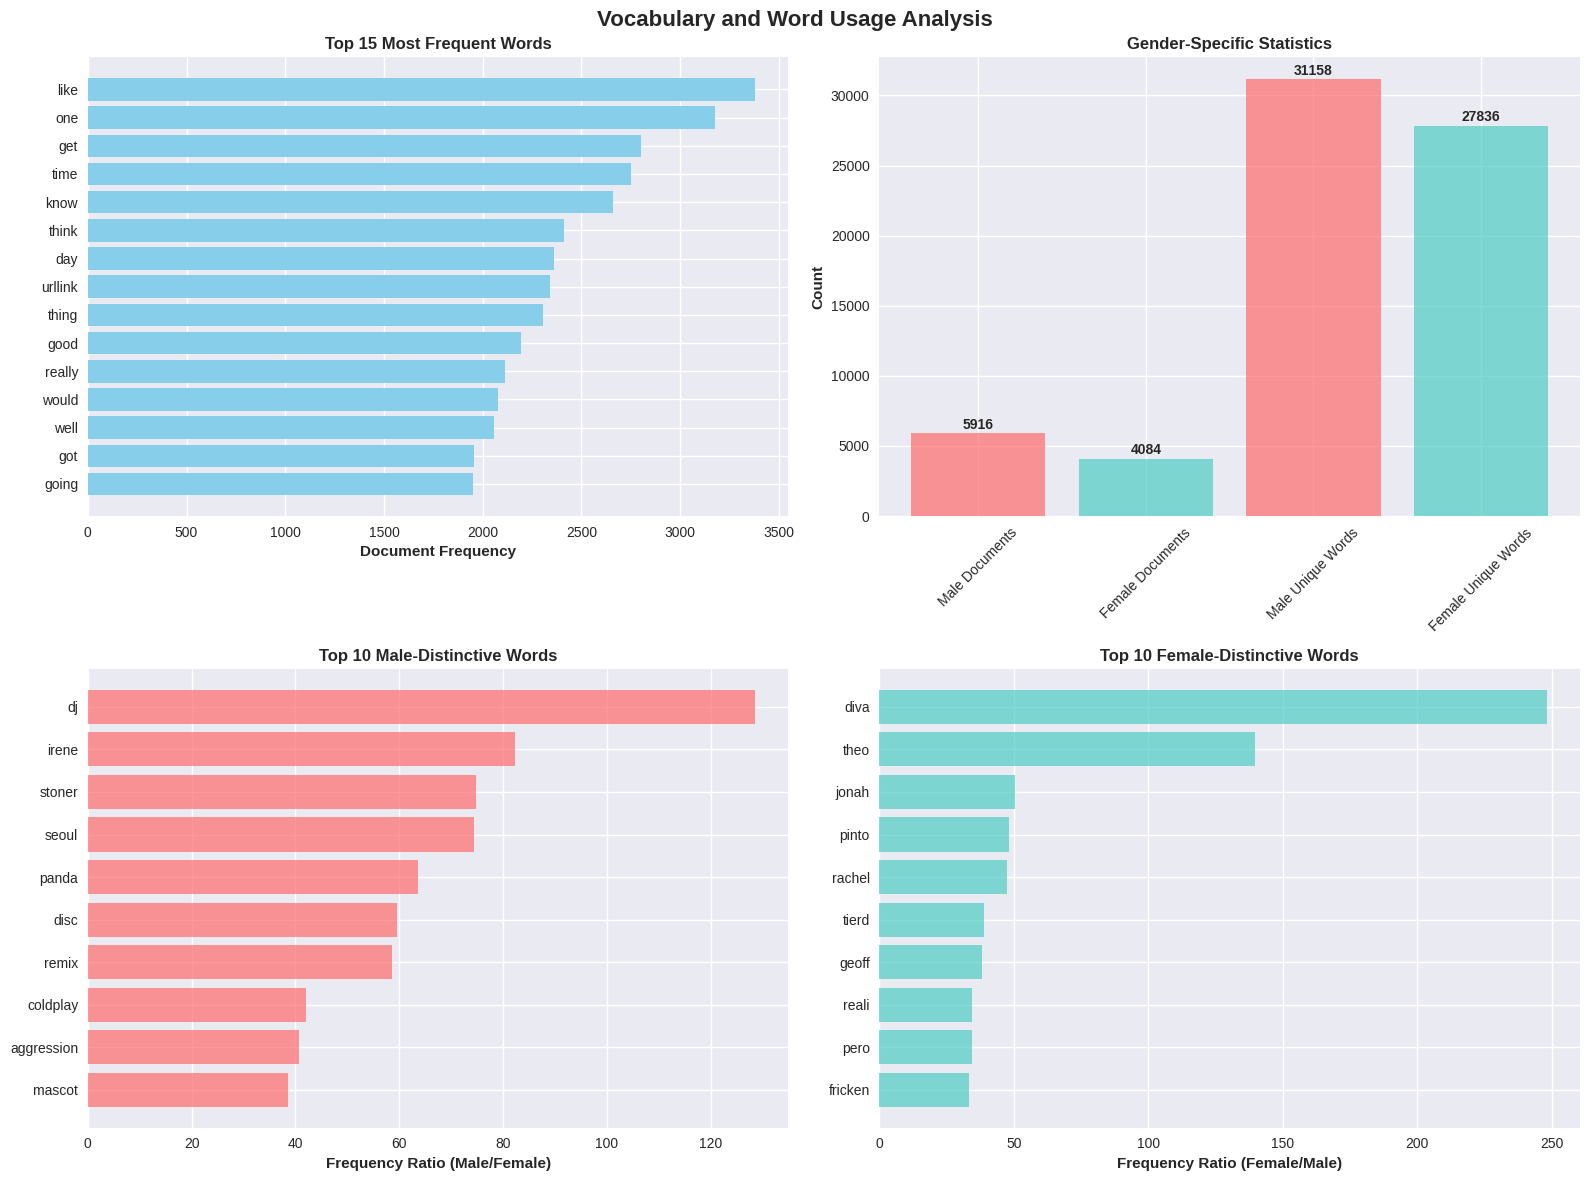

In [15]:
# Visualize vocabulary insights
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Vocabulary and Word Usage Analysis', fontsize=16, fontweight='bold')

# 1. Most frequent words overall
top_words, top_freqs = zip(*[(word, freq) for word, freq in most_common_words[:15] if word in vocab])
axes[0, 0].barh(range(len(top_words)), top_freqs, color='skyblue')
axes[0, 0].set_yticks(range(len(top_words)))
axes[0, 0].set_yticklabels(top_words)
axes[0, 0].set_xlabel('Document Frequency', fontweight='bold')
axes[0, 0].set_title('Top 15 Most Frequent Words', fontweight='bold')
axes[0, 0].invert_yaxis()

# 2. Gender-specific word counts
gender_stats = ['Male Documents', 'Female Documents', 'Male Unique Words', 'Female Unique Words']
gender_values = [len(male_texts), len(female_texts), len(male_word_freq), len(female_word_freq)]
colors = ['#FF6B6B', '#4ECDC4', '#FF6B6B', '#4ECDC4']
bars = axes[0, 1].bar(gender_stats, gender_values, color=colors, alpha=0.7)
axes[0, 1].set_ylabel('Count', fontweight='bold')
axes[0, 1].set_title('Gender-Specific Statistics', fontweight='bold')
for i, v in enumerate(gender_values):
    axes[0, 1].text(i, v + max(gender_values)*0.01, str(v), ha='center', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
# 3. Male-distinctive words
if male_distinctive_sorted:
    male_words, male_ratios, _, _ = zip(*male_distinctive_sorted[:10])
    axes[1, 0].barh(range(len(male_words)), male_ratios, color='#FF6B6B', alpha=0.7)
    axes[1, 0].set_yticks(range(len(male_words)))
    axes[1, 0].set_yticklabels(male_words)
    axes[1, 0].set_xlabel('Frequency Ratio (Male/Female)', fontweight='bold')
    axes[1, 0].set_title('Top 10 Male-Distinctive Words', fontweight='bold')
    axes[1, 0].invert_yaxis()

# 4. Female-distinctive words
if female_distinctive_sorted:
    female_words, female_ratios, _, _ = zip(*female_distinctive_sorted[:10])
    axes[1, 1].barh(range(len(female_words)), female_ratios, color='#4ECDC4', alpha=0.7)
    axes[1, 1].set_yticks(range(len(female_words)))
    axes[1, 1].set_yticklabels(female_words)
    axes[1, 1].set_xlabel('Frequency Ratio (Female/Male)', fontweight='bold')
    axes[1, 1].set_title('Top 10 Female-Distinctive Words', fontweight='bold')
    axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

In [16]:
# TF-IDF feature statistics
print(f"\nTF-IDF Feature Matrix Statistics:")
print(f"  - Matrix shape: {tfidf_matrix.shape}")
print(f"  - Matrix sparsity: {(tfidf_matrix == 0).sum() / tfidf_matrix.size * 100:.2f}% zeros")
print(f"  - Average non-zero features per document: {np.mean(np.count_nonzero(tfidf_matrix, axis=1)):.2f}")
print(f"  - Max TF-IDF value: {tfidf_matrix.max():.4f}")
print(f"  - Mean TF-IDF value (non-zero): {tfidf_matrix[tfidf_matrix > 0].mean():.4f}")



TF-IDF Feature Matrix Statistics:
  - Matrix shape: (10000, 11300)
  - Matrix sparsity: 99.50% zeros
  - Average non-zero features per document: 56.48
  - Max TF-IDF value: 1.0000
  - Mean TF-IDF value (non-zero): 0.0990


## 🤖 Section 5: Modèles d'Apprentissage Automatique Traditionnels


### Sélection de Modèles

In [17]:
models = [
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")),
    ("Linear SVM", LinearSVC(C=1.0, random_state=42, class_weight="balanced")),
    ("Multinomial NB", MultinomialNB(alpha=1.0)),
    ("Logistic Regression", LogisticRegression(solver="liblinear", random_state=42, class_weight="balanced")),
]


### Validation Croisée

In [18]:
# Cross-validation
print("Performing cross-validation...")
CV = 5
cv_results = []

for model_name, model in models:
    print(f"Evaluating {model_name}...")
    accuracies = cross_val_score(model, features, labels, scoring="accuracy", cv=CV)
    cv_results.append({
        'Model': model_name,
        'Mean_CV_Accuracy': accuracies.mean(),
        'Std_CV_Accuracy': accuracies.std(),
        'CV_Scores': accuracies
    })

# Display cross-validation results
cv_df = pd.DataFrame(cv_results)
print("\nCross-Validation Results:")
print(cv_df[['Model', 'Mean_CV_Accuracy', 'Std_CV_Accuracy']].round(4))

Performing cross-validation...
Evaluating Random Forest...
Evaluating Linear SVM...
Evaluating Multinomial NB...
Evaluating Logistic Regression...

Cross-Validation Results:
                 Model  Mean_CV_Accuracy  Std_CV_Accuracy
0        Random Forest            0.6586           0.0380
1           Linear SVM            0.6642           0.0478
2       Multinomial NB            0.6800           0.0351
3  Logistic Regression            0.6812           0.0419


In [19]:
# Train best model on full training set
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    features, labels, df.index, test_size=0.25, random_state=42, stratify=labels
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 7500
Test set size: 2500


In [20]:
# Train and evaluate each model
ml_results = []
trained_models = {}

for model_name, model in models:
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    ml_results.append({
        'Model': model_name,
        'Test_Accuracy': accuracy,
        'Predictions': y_pred
    })
    
    trained_models[model_name] = model
    
    print(f"{model_name} Test Accuracy: {accuracy:.4f}")


Training Random Forest...
Random Forest Test Accuracy: 0.7796

Training Linear SVM...
Linear SVM Test Accuracy: 0.7888

Training Multinomial NB...
Multinomial NB Test Accuracy: 0.8024

Training Logistic Regression...
Logistic Regression Test Accuracy: 0.7920


In [21]:
# Learning curves for top 3 models
from sklearn.model_selection import learning_curve

def plot_learning_curves(models_to_plot, X, y):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Learning Curves for Top 3 Models', fontsize=16, fontweight='bold')
    
    for idx, (model_name, model) in enumerate(models_to_plot[:3]):
        print(f"Computing learning curve for {model_name}...")
        train_sizes, train_scores, val_scores = learning_curve(
            model, X, y, cv=3, n_jobs=-1, 
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='accuracy', random_state=42
        )
        
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)
        val_std = np.std(val_scores, axis=1)
        
        axes[idx].plot(train_sizes, train_mean, 'o-', color='#FF6B6B', label='Training accuracy')
        axes[idx].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#FF6B6B')
        
        axes[idx].plot(train_sizes, val_mean, 'o-', color='#4ECDC4', label='Validation accuracy')
        axes[idx].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#4ECDC4')
        
        axes[idx].set_xlabel('Training Set Size', fontweight='bold')
        axes[idx].set_ylabel('Accuracy', fontweight='bold')
        axes[idx].set_title(f'{model_name}', fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()





Best Traditional ML Model: Multinomial NB (Accuracy: 0.8024)

Detailed Classification Report for Multinomial NB:
              precision    recall  f1-score   support

        male       0.79      0.91      0.85      1479
      female       0.84      0.64      0.73      1021

    accuracy                           0.80      2500
   macro avg       0.81      0.78      0.79      2500
weighted avg       0.81      0.80      0.80      2500



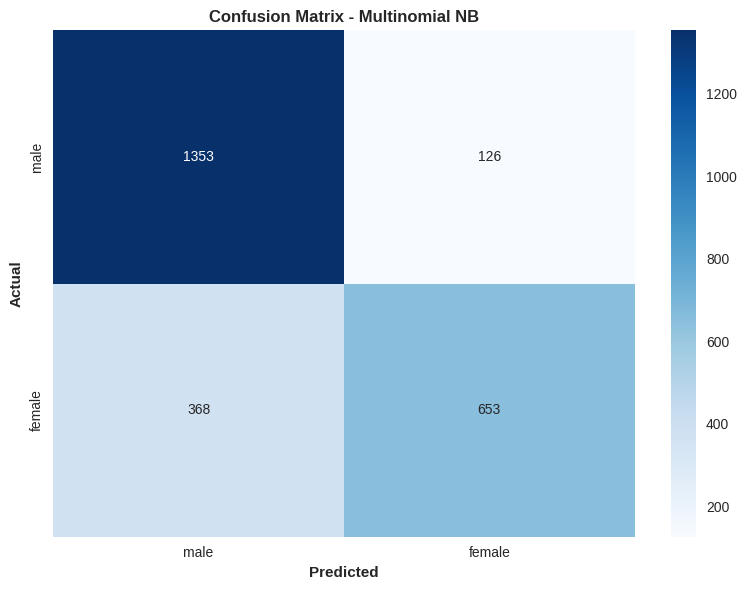

In [22]:
# Get top 3 models by accuracy
top_models = [(result['Model'], trained_models[result['Model']]) 
              for result in sorted(ml_results, key=lambda x: x['Test_Accuracy'], reverse=True)[:3]]

# Best traditional ML model
best_ml = max(ml_results, key=lambda x: x['Test_Accuracy'])
print(f"\nBest Traditional ML Model: {best_ml['Model']} (Accuracy: {best_ml['Test_Accuracy']:.4f})")

# Detailed evaluation of best model
print(f"\nDetailed Classification Report for {best_ml['Model']}:")
print(classification_report(y_test, best_ml['Predictions'], 
                          target_names=df["gender"].unique()))

# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
conf_mat = confusion_matrix(y_test, best_ml['Predictions'])
sns.heatmap(conf_mat, annot=True, cmap="Blues", fmt='d', 
            xticklabels=gender_id_df.gender.values, 
            yticklabels=gender_id_df.gender.values)
plt.ylabel("Actual", fontweight='bold')
plt.xlabel("Predicted", fontweight='bold')
plt.title(f"Confusion Matrix - {best_ml['Model']}", fontweight='bold')
plt.tight_layout()
plt.show()

## 🧠 Section 6: Apprentissage Profond - DistilBERT (Transformer)


In [23]:
# Custom Dataset class for PyTorch
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [24]:
# Prepare data for transformer
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["gender"])

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label_id"].tolist(),
    test_size=0.25,
    random_state=42,
    stratify=df["label_id"]
)

print(f"Transformer training samples: {len(train_texts)}")
print(f"Transformer test samples: {len(test_texts)}")

Transformer training samples: 7500
Transformer test samples: 2500


In [25]:
# Initialize tokenizer and datasets
print("Loading DistilBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
train_dataset = TextDataset(train_texts, train_labels, tokenizer)
test_dataset = TextDataset(test_texts, test_labels, tokenizer)


Loading DistilBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [26]:
# Data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [27]:
# Load model
print("Loading DistilBERT model...")
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_encoder.classes_)
).to(device)

Loading DistilBERT model...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [28]:
# Training setup
optimizer = AdamW(transformer_model.parameters(), lr=2e-5)
scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


In [29]:
# Training loop
print("Training DistilBERT model...")
epochs = 3
transformer_history = {'train_loss': [], 'val_accuracy': []}

Training DistilBERT model...


In [30]:

for epoch in range(epochs):
    # Training
    transformer_model.train()
    total_loss = 0
    
    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(scaler is not None)):
            outputs = transformer_model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

        if scaler:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")

    avg_train_loss = total_loss / len(train_loader)
    transformer_history['train_loss'].append(avg_train_loss)

    # Validation
    transformer_model.eval()
    preds, true_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)

            outputs = transformer_model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)

            preds.extend(predictions.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    val_accuracy = accuracy_score(true_labels, preds)
    transformer_history['val_accuracy'].append(val_accuracy)
    
    print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

transformer_final_accuracy = transformer_history['val_accuracy'][-1]
print(f"\nFinal DistilBERT Test Accuracy: {transformer_final_accuracy:.4f}")




Epoch 1/3, Batch 0/469, Loss: 0.6821
Epoch 1/3, Batch 100/469, Loss: 0.4536
Epoch 1/3, Batch 200/469, Loss: 0.6225
Epoch 1/3, Batch 300/469, Loss: 0.7433
Epoch 1/3, Batch 400/469, Loss: 0.3106
Epoch 1 - Train Loss: 0.5186, Val Accuracy: 0.7952
Epoch 2/3, Batch 0/469, Loss: 0.3854
Epoch 2/3, Batch 100/469, Loss: 0.4986
Epoch 2/3, Batch 200/469, Loss: 0.0958
Epoch 2/3, Batch 300/469, Loss: 0.1637
Epoch 2/3, Batch 400/469, Loss: 0.5050
Epoch 2 - Train Loss: 0.3324, Val Accuracy: 0.8164
Epoch 3/3, Batch 0/469, Loss: 0.1388
Epoch 3/3, Batch 100/469, Loss: 0.1276
Epoch 3/3, Batch 200/469, Loss: 0.3577
Epoch 3/3, Batch 300/469, Loss: 0.3103
Epoch 3/3, Batch 400/469, Loss: 0.0780
Epoch 3 - Train Loss: 0.1652, Val Accuracy: 0.8212

Final DistilBERT Test Accuracy: 0.8212



Classification Report:
              precision    recall  f1-score   support

      female       0.79      0.76      0.78      1021
        male       0.84      0.86      0.85      1479

    accuracy                           0.82      2500
   macro avg       0.82      0.81      0.81      2500
weighted avg       0.82      0.82      0.82      2500



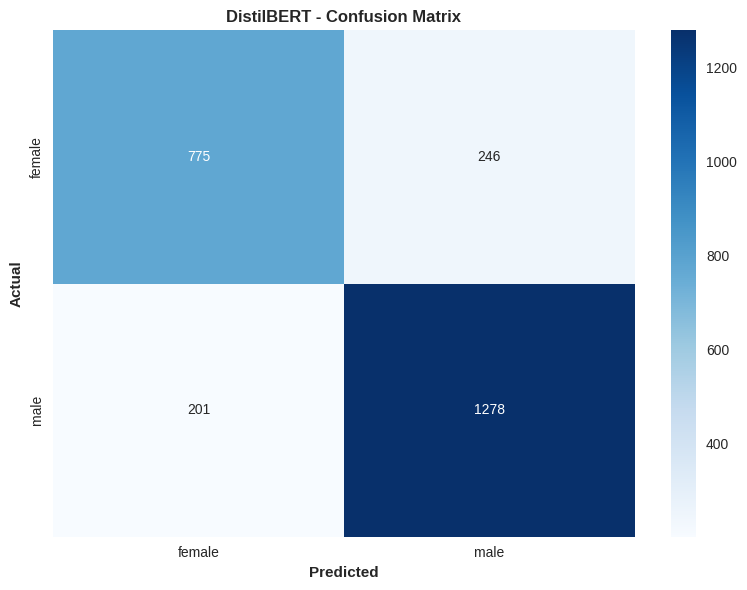

In [31]:
# Final report
print("\nClassification Report:")
print(classification_report(true_labels, preds, target_names=label_encoder.classes_))

conf_mat = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, cmap="Blues", fmt="d", 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("Actual", fontweight='bold')
plt.title("DistilBERT - Confusion Matrix", fontweight='bold')
plt.tight_layout()
plt.show()

## 🔄 Section 7: Apprentissage Profond - BiLSTM
### Pourquoi BiLSTM ?
- **LSTM** : Mémoire à Long et Court Terme (gère les données séquentielles)
- **Bidirectionnel** : Lit le texte gauche-à-droite ET droite-à-gauche
- **Traitement séquentiel** : Comprend l'ordre des mots (contrairement à TF-IDF)
- **Mémoire** : Peut se souvenir des motifs plus tôt dans le texte

In [32]:
def clean_text_simple(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [33]:
X_lstm = [clean_text_simple(t) for t in df["text"].astype(str)]
y_lstm = df["gender"].values

In [34]:
# Encode labels for Keras
encoder_lstm = LabelEncoder()
y_lstm_encoded = encoder_lstm.fit_transform(y_lstm)
y_lstm_categorical = to_categorical(y_lstm_encoded)

In [35]:
# Train-test split
X_train_lstm, X_val_lstm, y_train_lstm, y_val_lstm = train_test_split(
    X_lstm, y_lstm_categorical, test_size=0.2, random_state=42, stratify=y_lstm_categorical
)

print(f"BiLSTM training samples: {len(X_train_lstm)}")
print(f"BiLSTM validation samples: {len(X_val_lstm)}")


BiLSTM training samples: 8000
BiLSTM validation samples: 2000


In [36]:
# Tokenization and padding
max_words = 20000
max_len = 100

tokenizer_lstm = Tokenizer(num_words=max_words, lower=True, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(X_train_lstm)

X_train_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_train_lstm), maxlen=max_len)
X_val_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_val_lstm), maxlen=max_len)

print(f"BiLSTM input shape: {X_train_seq.shape}")

BiLSTM input shape: (8000, 100)


In [37]:
# Build BiLSTM model
print("Building BiLSTM model...")
bilstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(y_lstm_categorical.shape[1], activation="softmax")
])

bilstm_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

print("BiLSTM Model Architecture:")
bilstm_model.summary()

Building BiLSTM model...
BiLSTM Model Architecture:


I0000 00:00:1758839051.522368      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12424 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1758839051.523111      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Train BiLSTM model
print("Training BiLSTM model...")
bilstm_history = bilstm_model.fit(
    X_train_seq, y_train_lstm,
    validation_data=(X_val_seq, y_val_lstm),
    batch_size=64,
    epochs=5,
    verbose=1
)

Training BiLSTM model...
Epoch 1/5


I0000 00:00:1758839058.553124     140 cuda_dnn.cc:529] Loaded cuDNN version 90300


125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.6179 - loss: 0.6560 - val_accuracy: 0.7220 - val_loss: 0.5472
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8051 - loss: 0.4377 - val_accuracy: 0.7875 - val_loss: 0.4748
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9255 - loss: 0.2043 - val_accuracy: 0.7655 - val_loss: 0.6207
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9575 - loss: 0.1123 - val_accuracy: 0.7695 - val_loss: 0.8746
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9735 - loss: 0.0750 - val_accuracy: 0.7565 - val_loss: 0.8695


In [39]:
# Evaluate BiLSTM
bilstm_loss, bilstm_accuracy = bilstm_model.evaluate(X_val_seq, y_val_lstm, verbose=0)
print(f"\nBiLSTM Validation Accuracy: {bilstm_accuracy:.4f}")



BiLSTM Validation Accuracy: 0.7565


## 📊 Section 8: Comparaison de Modèles et Visualisation


In [40]:
all_results = []


In [41]:
# Traditional ML results
for result in ml_results:
    all_results.append({
        'Model': result['Model'],
        'Type': 'Traditional ML',
        'Accuracy': result['Test_Accuracy'],
        'Training_Time': 'Fast',
        'Complexity': 'Low'
    })

In [42]:
# Add deep learning results
all_results.append({
    'Model': 'DistilBERT',
    'Type': 'Transformer',
    'Accuracy': transformer_final_accuracy,
    'Training_Time': 'Slow',
    'Complexity': 'High'
})

In [43]:
all_results.append({
    'Model': 'BiLSTM',
    'Type': 'Deep Learning',
    'Accuracy': bilstm_accuracy,
    'Training_Time': 'Medium',
    'Complexity': 'Medium'
})

In [44]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\nFINAL MODEL COMPARISON TABLE:")
print("="*50)
print(comparison_df.round(4))


FINAL MODEL COMPARISON TABLE:
                 Model            Type  Accuracy Training_Time Complexity
0           DistilBERT     Transformer    0.8212          Slow       High
1       Multinomial NB  Traditional ML    0.8024          Fast        Low
2  Logistic Regression  Traditional ML    0.7920          Fast        Low
3           Linear SVM  Traditional ML    0.7888          Fast        Low
4        Random Forest  Traditional ML    0.7796          Fast        Low
5               BiLSTM   Deep Learning    0.7565        Medium     Medium


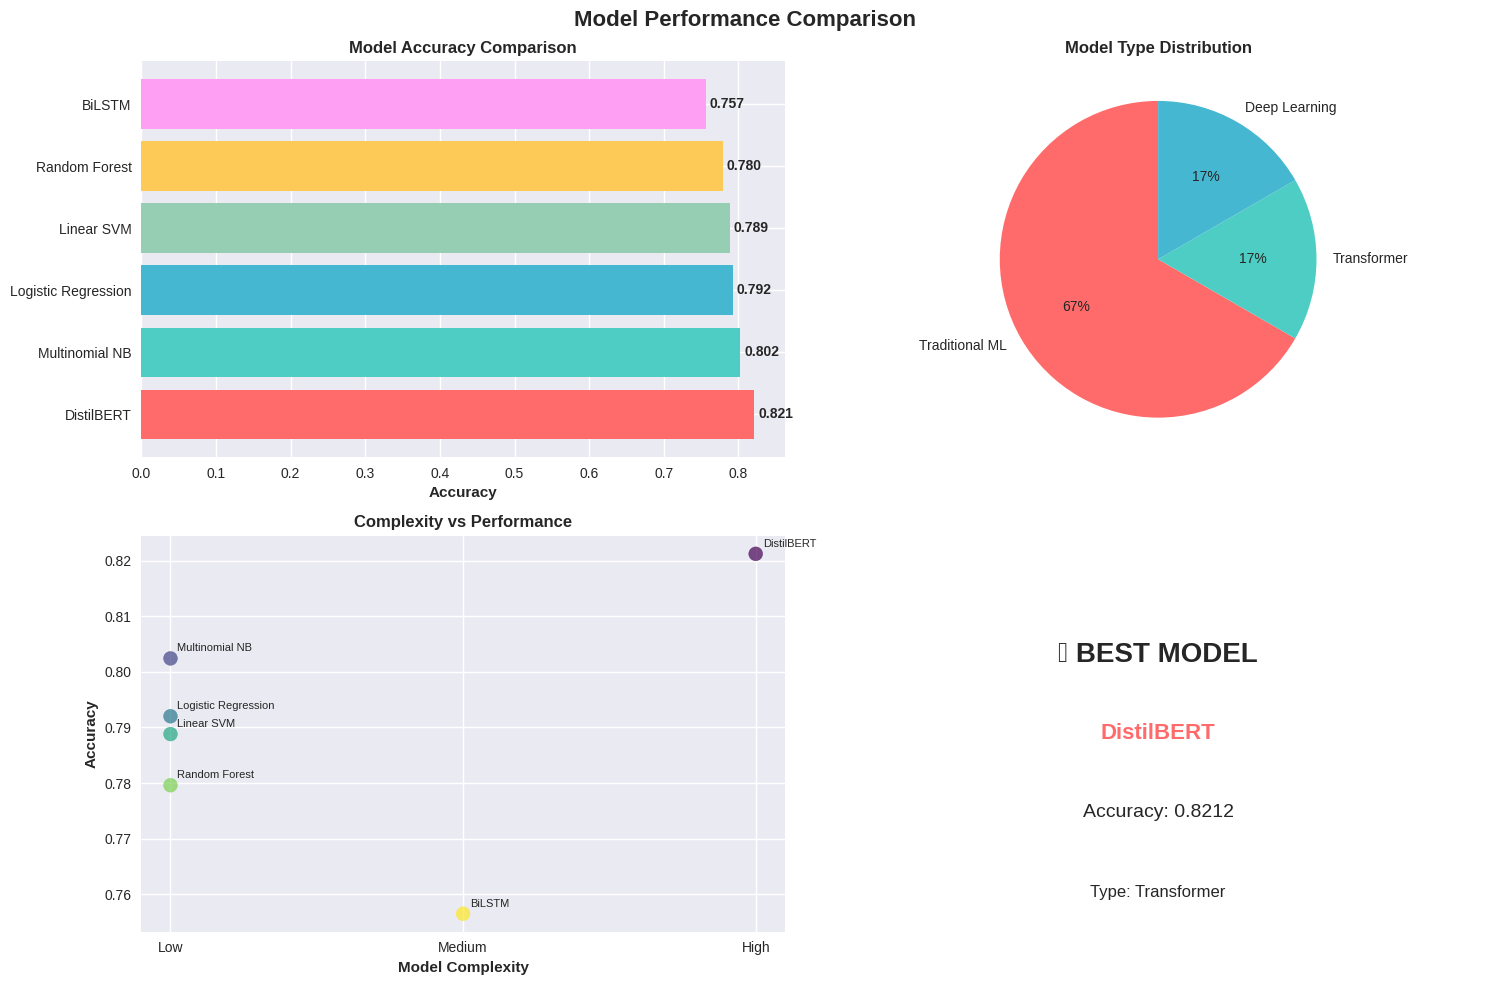

In [45]:
# Visualization of model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Accuracy comparison
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
bars = axes[0, 0].barh(comparison_df['Model'], comparison_df['Accuracy'], color=colors[:len(comparison_df)])
axes[0, 0].set_xlabel('Accuracy', fontweight='bold')
axes[0, 0].set_title('Model Accuracy Comparison', fontweight='bold')
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0, 0].text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')

# Model type distribution
type_counts = comparison_df['Type'].value_counts()
axes[0, 1].pie(type_counts.values, labels=type_counts.index, autopct='%1.0f%%',
               colors=['#FF6B6B', '#4ECDC4', '#45B7D1'], startangle=90)
axes[0, 1].set_title('Model Type Distribution', fontweight='bold')

# Training complexity vs accuracy
complexity_map = {'Low': 1, 'Medium': 2, 'High': 3}
comparison_df['Complexity_Numeric'] = comparison_df['Complexity'].map(complexity_map)
scatter = axes[1, 0].scatter(comparison_df['Complexity_Numeric'], comparison_df['Accuracy'], 
                           c=range(len(comparison_df)), cmap='viridis', s=100, alpha=0.7)
axes[1, 0].set_xlabel('Model Complexity', fontweight='bold')
axes[1, 0].set_ylabel('Accuracy', fontweight='bold')
axes[1, 0].set_title('Complexity vs Performance', fontweight='bold')
axes[1, 0].set_xticks([1, 2, 3])
axes[1, 0].set_xticklabels(['Low', 'Medium', 'High'])
for i, model in enumerate(comparison_df['Model']):
    axes[1, 0].annotate(model, (comparison_df['Complexity_Numeric'].iloc[i], 
                              comparison_df['Accuracy'].iloc[i]), 
                       xytext=(5, 5), textcoords='offset points', fontsize=8)

# Best model highlight
best_model = comparison_df.iloc[0]
axes[1, 1].text(0.5, 0.7, f"🏆 BEST MODEL", ha='center', va='center', 
                fontsize=20, fontweight='bold', transform=axes[1, 1].transAxes)
axes[1, 1].text(0.5, 0.5, f"{best_model['Model']}", ha='center', va='center', 
                fontsize=16, fontweight='bold', color='#FF6B6B', transform=axes[1, 1].transAxes)
axes[1, 1].text(0.5, 0.3, f"Accuracy: {best_model['Accuracy']:.4f}", ha='center', va='center', 
                fontsize=14, transform=axes[1, 1].transAxes)
axes[1, 1].text(0.5, 0.1, f"Type: {best_model['Type']}", ha='center', va='center', 
                fontsize=12, transform=axes[1, 1].transAxes)
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


## 💾 Section 9: Sauvegarde de Modèles


In [46]:
import os
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

In [47]:
# Save traditional ML models
print("Saving traditional ML models...")
for model_name, model in trained_models.items():
    filename = f"{save_dir}/{model_name.replace(' ', '_').lower()}_model.pkl"
    joblib.dump(model, filename)
    print(f"Saved {model_name} to {filename}")

Saving traditional ML models...
Saved Random Forest to saved_models/random_forest_model.pkl
Saved Linear SVM to saved_models/linear_svm_model.pkl
Saved Multinomial NB to saved_models/multinomial_nb_model.pkl
Saved Logistic Regression to saved_models/logistic_regression_model.pkl


In [48]:
# Save preprocessing components
print("\nSaving preprocessing components...")
preprocessing_components = {
    'tfidf_matrix': tfidf_matrix,
    'vocab': vocab,
    'word_to_index': word_to_index,
    'gender_to_id': gender_to_id,
    'id_to_gender': id_to_gender
}
joblib.dump(preprocessing_components, f"{save_dir}/preprocessing_components.pkl")
print("Saved preprocessing components")


Saving preprocessing components...
Saved preprocessing components


In [49]:
# Save transformer model
print("\nSaving DistilBERT model...")
transformer_model.save_pretrained(f"{save_dir}/distilbert_model")
tokenizer.save_pretrained(f"{save_dir}/distilbert_tokenizer")
torch.save({
    'model_state_dict': transformer_model.state_dict(),
    'label_encoder': label_encoder,
    'training_history': transformer_history
}, f"{save_dir}/distilbert_checkpoint.pth")
print("Saved DistilBERT model and tokenizer")


Saving DistilBERT model...
Saved DistilBERT model and tokenizer


In [50]:
# Save BiLSTM model
print("\nSaving BiLSTM model...")
bilstm_model.save(f"{save_dir}/bilstm_model.h5")
with open(f"{save_dir}/bilstm_tokenizer.pkl", 'wb') as f:
    pickle.dump(tokenizer_lstm, f)
joblib.dump({
    'encoder': encoder_lstm,
    'max_words': max_words,
    'max_len': max_len,
    'history': bilstm_history.history
}, f"{save_dir}/bilstm_components.pkl")
print("Saved BiLSTM model and components")


Saving BiLSTM model...
Saved BiLSTM model and components


In [52]:
# Save comparison results
print("\nSaving comparison results...")
comparison_df.to_csv(f"{save_dir}/model_comparison_results.csv", index=False)
print("Saved model comparison results")

print(f"\n All models and components saved successfully in '{save_dir}/' directory!")
print("\nFiles saved:")
for file in os.listdir(save_dir):
    print(f"  - {file}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"Best performing model: {best_model['Model']} with {best_model['Accuracy']:.4f} accuracy")
print("All models have been trained, evaluated, and saved successfully!")


Saving comparison results...
Saved model comparison results

 All models and components saved successfully in 'saved_models/' directory!

Files saved:
  - distilbert_checkpoint.pth
  - model_comparison_results.csv
  - random_forest_model.pkl
  - logistic_regression_model.pkl
  - distilbert_tokenizer
  - bilstm_tokenizer.pkl
  - preprocessing_components.pkl
  - bilstm_model.h5
  - linear_svm_model.pkl
  - bilstm_components.pkl
  - distilbert_model
  - multinomial_nb_model.pkl

ANALYSIS COMPLETE!
Best performing model: DistilBERT with 0.8212 accuracy
All models have been trained, evaluated, and saved successfully!
